# Multi-basin season — ACE by basin

Request two basins (North Atlantic + East Pacific) in **one** call and compare their storm counts and Accumulated Cyclone Energy (ACE) for the 2018 season. Track-mode query: one `LineString` per storm, with a per-storm `ace` and a `basin` column. `download()` returns the union across both basins.

In [1]:
from pathlib import Path

from earthlens import EarthLens

OUT_DIR = Path('tropycal_output')
OUT_DIR.mkdir(exist_ok=True)

In [2]:
tracks = None
try:
    tracks = EarthLens(
        variables=['north_atlantic', 'east_pacific'],
        data_source='tropycal',
        start='2018-05-01',
        end='2018-12-01',
        aoi=[-160.0, 0.0, -10.0, 60.0],
        source='hurdat',
        geometry='track',
        path=str(OUT_DIR),
    ).download(progress_bar=False)
    print(len(tracks), 'storm tracks across', tracks['basin'].nunique(), 'basins')
except Exception as exc:
    print(f'skipped live query: {type(exc).__name__}: {exc}')

2026-05-23 18:47:40 | INFO | pyramids.base.config | Logging is configured.


C:\python-environments\pixi\envs\earthlens-7782220113782294872\envs\dev\Lib\site-packages\tropycal\_version.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


2026-05-23 18:47:41.893 | INFO     | earthlens.tropycal.backend:_get_track_dataset:378 - Loading tropycal TrackDataset(basin='north_atlantic', source='hurdat'); the first load downloads + parses the whole basin best-track file and can be slow.


--> Starting to read in HURDAT2 data


--> Completed reading in HURDAT2 data (3.12 seconds)


...

--> Completed reading in HURDAT2 data (1.87 seconds)


2026-05-23 18:48:01 | INFO | pyogrio._io | Created 16 records


2026-05-23 18:48:01 | INFO | pyogrio._io | Created 26 records


2026-05-23 18:48:01.800 | INFO     | earthlens.tropycal.backend:download:514 - Tropycal download summary: 42 feature(s) across 2 file(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\tropycal\docs\examples\tropycal\tropycal_output


42 storm tracks across 2 basins


In [3]:
if tracks is not None and len(tracks):
    summary = tracks.groupby('basin').agg(
        storms=('name', 'nunique'), total_ace=('ace', 'sum')
    )
    print(summary)

                storms  total_ace
basin                            
east_pacific        26   318.7800
north_atlantic      16   132.5825


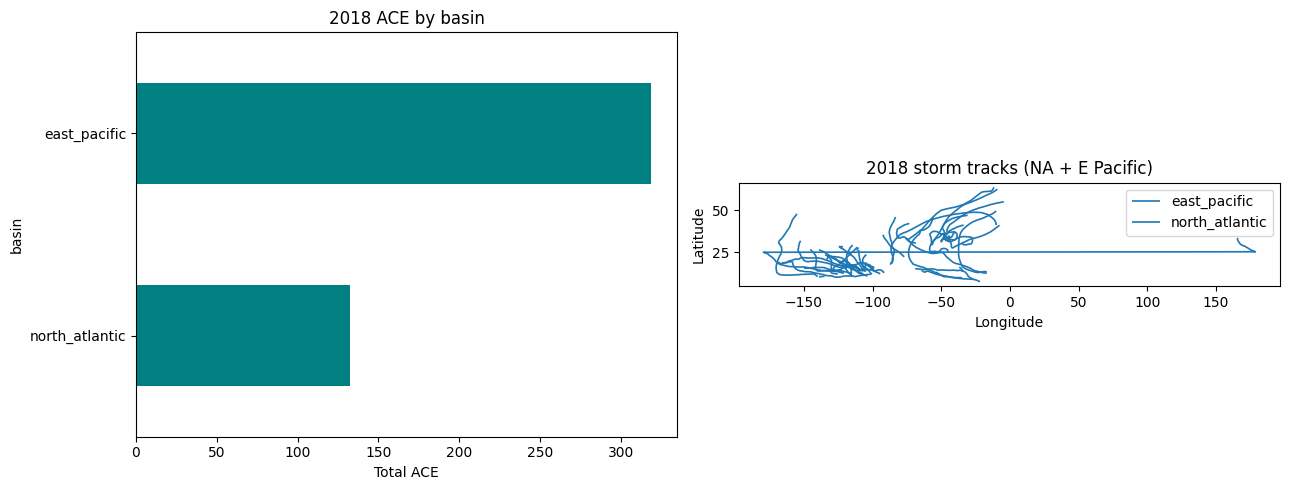

In [4]:
if tracks is not None and len(tracks):
    import matplotlib.pyplot as plt

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    tracks.groupby('basin')['ace'].sum().sort_values().plot.barh(
        ax=ax1, color='teal'
    )
    ax1.set_xlabel('Total ACE')
    ax1.set_title('2018 ACE by basin')
    for basin, grp in tracks.groupby('basin'):
        grp.plot(ax=ax2, linewidth=1.2, label=basin)
    ax2.set_title('2018 storm tracks (NA + E Pacific)')
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.legend()
    plt.tight_layout()
    plt.show()